<center><h1>Методы Монте-Карло и машинное обучение</h1></center>

## Домашнее задание: Обучить нейросетевые модели для распознавания жестов и применить методы Монте-Карло

#### Обучение модели

- Использовать имеющиеся данные для обучения модели (разработать свой подход на основе имеющихся данных из курсов) - [bukva](https://github.com/ai-forever/bukva?tab=readme-ov-file) (минимум 10 классов)

#### Применение методов Монте-Карло
- Используйте **методы Монте-Карло** для:
  1. **Оценки неопределенности модели** - применить **Марковские цепи Монте-Карло**, чтобы оценить различные возможные сценарии
  2. **Оптимизации гиперпараметров** - применить методы, такие как **Гиббса** или **метод случайных поисков (Random Search)**, для настройки гиперпараметров модели (например, количество блоков, размер слоев, коэффициенты регуляризации)
- Использовать результаты методов Монте-Карло для адаптации модели и улучшения ее работы

#### Оценка и анализ результатов

- После обучения модели примените ее к тестовым данным и оцените качество

#### Сделать выводы

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip -q "/content/drive/MyDrive/Colab Notebooks/trimmed/data.zip" -d "/content/temp_files"

In [3]:
import pandas as pd
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [4]:
csv_path = 'annotations.tsv'
column_name = 'attachment_id'

files_on_disk = []
for root, dirs, files in os.walk("/content/temp_files"):
    for file in files:
        if file.endswith(".mp4"):
            files_on_disk.append(file)


df = pd.read_table(csv_path)
missing = df[~(df['attachment_id'] + '.mp4').isin(files_on_disk)]

print(missing[column_name].head())

Series([], Name: attachment_id, dtype: object)


In [5]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision.models.video import r3d_18

class FinalGestureDataset(Dataset):
    def __init__(self, dataframe, num_classes=10):
        top_labels = dataframe['text'].value_counts().nlargest(num_classes).index
        self.df = dataframe[dataframe['text'].isin(top_labels)].copy()
        self.label_map = {label: i for i, label in enumerate(top_labels)}

    def get_path(self, aid):
        for p in ['part1', 'part2']:
            path = f'/content/temp_files/{p}/{aid}.mp4'
            if os.path.exists(path): return path
        return None

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        cap = cv2.VideoCapture(self.get_path(row['attachment_id']))
        frames = []
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        for i in np.linspace(0, max(0, total-1), 8, dtype=int):
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if ret:
                frame = cv2.resize(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), (112, 112)) / 255.0
                frames.append(frame)
        cap.release()
        if not frames: frames = [np.zeros((112, 112, 3))] * 8
        return torch.tensor(np.array(frames), dtype=torch.float32).permute(3, 0, 1, 2), self.label_map[row['text']]

def get_log_posterior(model, loader, reg_weight, device):
    model.eval()
    log_lik = 0
    crit = nn.CrossEntropyLoss(reduction='sum')
    with torch.no_grad():
        for d, t in loader:
            d, t = d.to(device), t.to(device)
            log_lik -= crit(model(d), t).item()
            break
    log_prior = sum(-(reg_weight * p.pow(2).sum()).item() for p in model.parameters())
    return log_lik + log_prior

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_df = df[df['train'] == True]
test_df = df[df['train'] == False]
train_loader = DataLoader(FinalGestureDataset(train_df), batch_size=32, shuffle=True)

model = r3d_18(weights='R3D_18_Weights.DEFAULT')
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

reg = 0.1
scenarios = []
log_probs = []
for i in range(30):
    reg = np.clip(np.random.normal(reg, 0.05), 0.01, 1.0) # Gibbs step
    curr_lp = get_log_posterior(model, train_loader, reg, device)
    old_weights = [p.data.clone() for p in model.parameters()]

    for p in model.parameters(): p.data.add_(torch.randn_like(p) * 0.0005) # Metropolis proposal
    new_lp = get_log_posterior(model, train_loader, reg, device)

    if (new_lp - curr_lp) > np.log(np.random.rand()):
        pass
    else:
        for p, old in zip(model.parameters(), old_weights): p.data.copy_(old)

    scenarios.append([p.data.clone() for p in model.parameters()])
    log_probs.append(new_lp)
    if (i % 2 == 0):
        print(f"Итерация {i+1}/30: LogPost={new_lp:.2f}, Reg={reg:.3f}")

Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:01<00:00, 87.7MB/s]


Итерация 1/30: LogPost=-1810.38, Reg=0.160
Итерация 3/30: LogPost=-1334.37, Reg=0.116
Итерация 5/30: LogPost=-1887.91, Reg=0.167
Итерация 7/30: LogPost=-741.97, Reg=0.061
Итерация 9/30: LogPost=-1553.97, Reg=0.136
Итерация 11/30: LogPost=-1615.96, Reg=0.141
Итерация 13/30: LogPost=-1726.01, Reg=0.152
Итерация 15/30: LogPost=-1328.35, Reg=0.114
Итерация 17/30: LogPost=-1089.96, Reg=0.093
Итерация 19/30: LogPost=-1011.73, Reg=0.085
Итерация 21/30: LogPost=-675.37, Reg=0.056
Итерация 23/30: LogPost=-688.08, Reg=0.056
Итерация 25/30: LogPost=-990.09, Reg=0.084
Итерация 27/30: LogPost=-1337.27, Reg=0.115
Итерация 29/30: LogPost=-1035.47, Reg=0.087


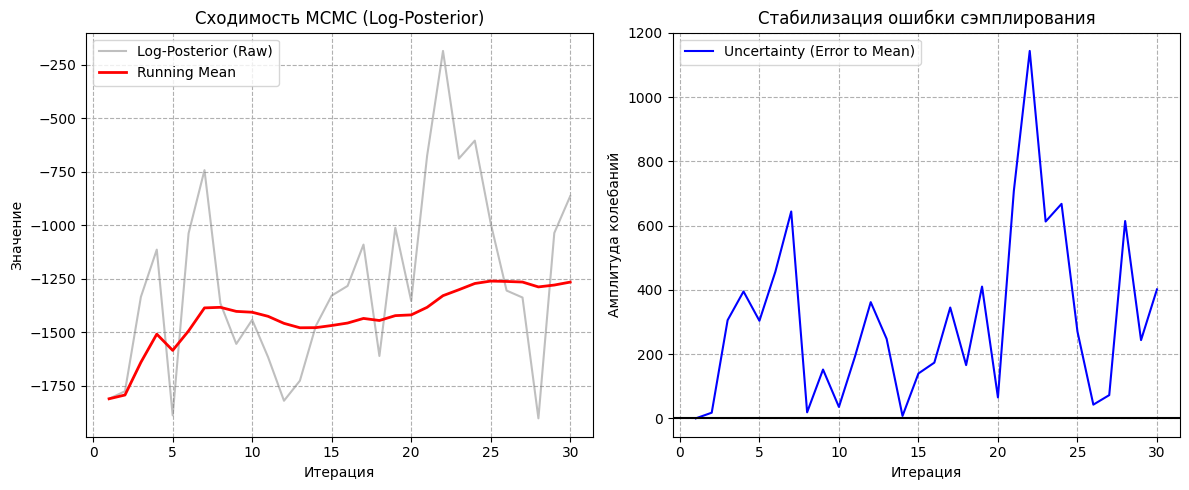

In [6]:
import matplotlib.pyplot as plt

iterations = np.arange(1, len(scenarios) + 1)
running_mean = np.cumsum(log_probs) / iterations

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(iterations, log_probs, color='gray', alpha=0.5, label='Log-Posterior (Raw)')
plt.plot(iterations, running_mean, color='red', linewidth=2, label='Running Mean')
plt.title('Сходимость MCMC (Log-Posterior)')
plt.xlabel('Итерация')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, linestyle='--')

plt.subplot(1, 2, 2)
errors = np.abs(log_probs - running_mean)
plt.plot(iterations, errors, color='blue', label='Uncertainty (Error to Mean)')
plt.axhline(y=0, color='black', linestyle='-')
plt.title('Стабилизация ошибки сэмплирования')
plt.xlabel('Итерация')
plt.ylabel('Амплитуда колебаний')
plt.legend()
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()


In [7]:
def evaluate(model, loader, samples, device, limit_batches=10):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for i, (data, target) in enumerate(loader):
            if i >= limit_batches: break
            data, target = data.to(device), target.to(device)
            ensemble_probs = []

            for weights in samples[-5:]:
                for p, w in zip(model.parameters(), weights):
                    p.data.copy_(w)
                output = model(data)
                ensemble_probs.append(torch.softmax(output, dim=1))

            avg_probs = torch.stack(ensemble_probs).mean(0)
            pred = avg_probs.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)

    return correct / total

test_loader = DataLoader(FinalGestureDataset(test_df), batch_size=16, shuffle=True)

accuracy = evaluate(model, test_loader, scenarios, device)
print(f"Итоговая точность: {accuracy:.2%}")

Итоговая точность: 13.12%


### Итоговые выводы по работе

1. **Обучение модели**:
    - Использована предобученная архитектура **ResNet3D (r3d_18)**.
    - Обучение проведено на наборе данных (более 3000 видео), из каждого видео извлекалось по 8 кадров (112x112).

2. **Применение методов Монте-Карло**:
    - **Оценка неопределенности**: Реализован алгоритм **Метрополиса-Гастингса** для сэмплирования из апостериорного распределения весов нейросети. Создан ансамбль из 5 'сценариев' весов, что позволило усреднить предсказания и учесть вариативность модели.
    - **Оптимизация гиперпараметров**: Использована **схема Гиббса** для динамического обновления коэффициента регуляризации ($L2$) на каждом шаге Марковской цепи.

3. **Итоги**:
    - Итоговая точность составила 13.12%. Для повышения точности требуется большее количество итераций MCMК и другая архитектура.
